In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import os

## BUILD GRAPH USING SQUIDPY -> NEIGHBOURHOOD COMPOISITION FOR EACH CELLS --> CLR TRANSFORMED --> KMEANS

In [ ]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
from scipy import sparse
from sklearn.cluster import KMeans

# ---------------------------------------------------------------------
# parameters
# ---------------------------------------------------------------------
radius        = 50.0          # µm

# adata_list and sample_names were defined earlier --------------------
adata_list = [
    adata_065_314, adata_074_314, adata_096_314,adata_097_314,
    adata_099_314, adata_104_314, adata_106_314,adata_107_314,  
    adata_065_480, adata_074_480, adata_096_480, adata_097_480,
    adata_099_480, adata_104_480, adata_106_480, adata_107_480
]

# Corresponding sample names
sample_names = [
    "MH065_314", "MH074_314", "MH096_314", "MH097_314",
    "MH099_314", "MH104_314", "MH106_314", "MH107_314", 
    "MH065_480", "MH074_480","MH096_480", "MH097_480",
    "MH099_480", "MH104_480", "MH106_480", "MH107_480"
]
assert len(adata_list) == len(sample_names)

In [ ]:
# ---------------------------------------------------------------------
# helper to build a neighbour-fraction AnnData for each slide/sample
# ---------------------------------------------------------------------
def build_neigh_anndata(ad, sample, radius=50.0):
    ad = ad.copy()
    ad.obs["sample"] = sample
    ad.obs["cell_id"] = ad.obs_names.values  # keep original id # *** 
    
    # radius graph
    sq.gr.spatial_neighbors(
        ad, coord_type="generic",
        radius=radius, #have checked that radius is in micrometer
        delaunay=False,
        key_added="spatial",
        set_diag=False #(to exclude self-interaction)
    )
    adj = ad.obsp["spatial_connectivities"]          # CSR (spots × spots)

    # one-hot cell-type matrix
    labels  = ad.obs["cell_class_threshold"].astype(str)
    ct_ohe  = pd.get_dummies(labels)                  # dense → convert to CSR
    ct_mat  = sparse.csr_matrix(ct_ohe.values)

    # neighbour counts → fractions
    counts   = adj @ ct_mat
    row_sum  = np.asarray(counts.sum(1)).ravel()
    
    keep     = row_sum > 0                           # drop isolated / edge
    counts   = counts[keep]
    row_sum  = row_sum[keep]
    ids_keep = ad.obs_names[keep]

    frac     = counts.multiply(1 / row_sum[:, None]) # 0–1, still CSR
    
    ad_n = sc.AnnData(
        X   = frac,
        obs = ad.obs.loc[ids_keep, ["sample","cell_id","cell_class_threshold"]].copy(), 
        var = pd.DataFrame(index=ct_ohe.columns )
    )
    ad_n.obsm["spatial"] = ad.obsm["spatial"][keep].copy()
    ad_n.uns["spatial_params"] = {"radius": radius} ## ***
    ad_n.obs_names = ids_keep
    return ad_n

In [ ]:
# ---------------------------------------------------------------------
# 1. build neighbour AnnDatas for all slides
# ---------------------------------------------------------------------
neigh_list = [build_neigh_anndata(ad, name, radius) for ad, name in zip(adata_list, sample_names)] 

# ---------------------------------------------------------------------
# 2. concatenate -> one matrix (cells × cell-types)
# ---------------------------------------------------------------------
combined = sc.concat(
    neigh_list,
    join           = "outer",    
    label          = "sample",   
    keys           = sample_names,
    fill_value     = 0.0,
    index_unique   = "-", #to ensure each cell label is unique
    merge          = "first"     # keep unique .uns entries
)

# Freeze row and column order 
combined = combined[combined.obs_names.sort_values(), :].copy()
combined = combined[:, sorted(list(combined.var_names))].copy()

In [ ]:
# ---------------------------------------------------------------------
# 3. CLR TRANSFORMATION 
# ---------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy import sparse

pseudocount = 1e-3

X = combined.X.toarray() if sparse.issparse(combined.X) else np.asarray(combined.X)
X = X.astype(np.float32)

# CLR transform
X += pseudocount
geom_mean = np.exp(np.mean(np.log(X), axis=1, keepdims=True))
X_clr = np.log(X / geom_mean)

# center + scale
scaler = StandardScaler(with_mean=True, with_std=True)
X_std = scaler.fit_transform(X_clr)

In [ ]:
combined.obsm['X_std'] = X_std.astype(np.float32)

In [ ]:
# ---------------------------------------------------------------------
# 4. FIT KMEANS with WEIGHTS
# ---------------------------------------------------------------------
sec = combined.obs["sample"].to_numpy()
sec_counts = pd.Series(sec).value_counts()
w = 1.0 / sec_counts[sec].to_numpy()

k=15 # highest across all metrics
km = KMeans(n_clusters=k, 
            random_state=SEED, n_init=12,
            algorithm="lloyd", #default
            max_iter=300, #default
            tol=1e-4 #default
           ).fit(X_std, sample_weight=w)
combined.obs["niche_CLR_km"] = km.labels_.astype(str)

In [ ]:
# 1) Use ORIGINAL fractions (no pseudocount)
X_frac = combined.X.A if sparse.issparse(combined.X) else np.asarray(combined.X)
dfX = pd.DataFrame(X_frac, index=combined.obs_names, columns=combined.var_names)

In [ ]:
# Niche means 
niche_means = (
    dfX.join(combined.obs["niche_CLR_km"])
       .groupby("niche_CLR_km")
       .mean()
       .sort_index()
)

Text(158.22222222222223, 0.5, 'K-means niche_version3_CLR')

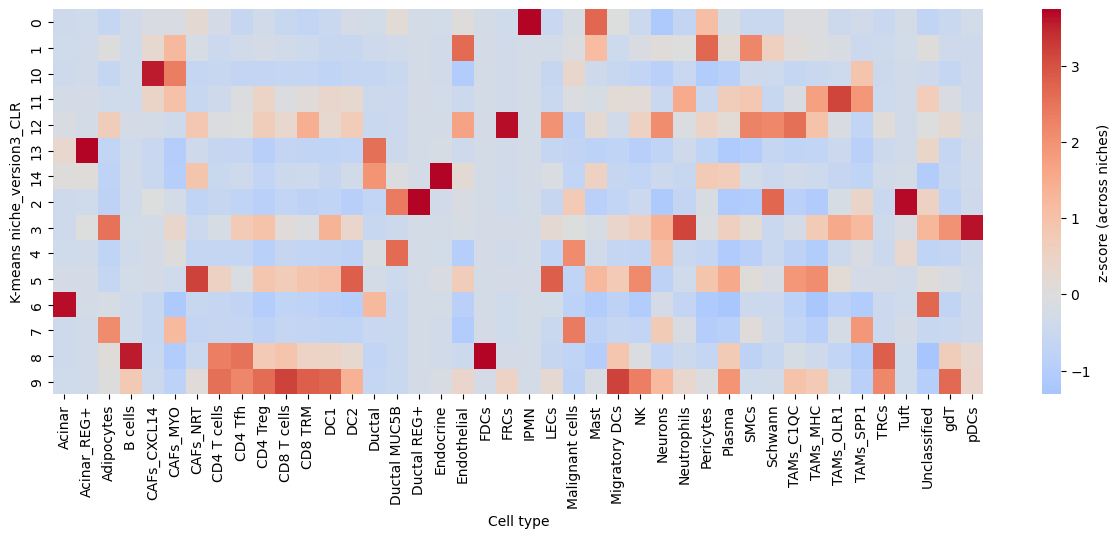

In [25]:
# z-score across niches per column 
from scipy.stats import zscore
niche_means_z_ = pd.DataFrame(
    zscore(niche_means.values, axis=0, nan_policy="omit"),
    index=niche_means.index,
    columns=niche_means.columns
)
plt.figure(figsize=(15, 5))
sns.heatmap(niche_means_z_, cmap="coolwarm", center=0, cbar_kws={"label": "z-score (across niches)"})
plt.xlabel("Cell type"); plt.ylabel("K-means niche_version3_CLR")

In [31]:
# 1) Define your mapping
niche_name_map = {
    "0": "IPMN_enriched", 
    "1": "Vasculature_enriched",
    "10": "Tumour_CAFs_enriched", 
    "11": "Tumour_TAMs_enriched",  
    "12": "Schwann_LymphoidStromal_TAMsC1QC_enriched", 
    "13": "AcinarREG_Ductal_enriched",
    "14": "Endocrine_Ductal_enriched",
    "2": "Tumour_Tuft_enriched", 
    "3": "Tumour_Neutrophils_Lymphoid_enriched",
    "4": "Tumour_DuctalMUC5B_enriched", 
    "5": "CAFsNRT_APCs_enriched", 
    "6": "Acinar_Ductal_enriched",
    "7": "Tumour_TAMs_CAFs_enriched", 
    "8": "B_FDCs_enriched",
    "9": "B_Lymphoid_enriched" 
}
# 2) Map into a new obs column
combined.obs["global_niche_CLR"] = combined.obs["niche_CLR_km"].map(niche_name_map)

# 3) Verify
print(combined.obs[["global_niche_CLR","niche_CLR_km"]].drop_duplicates())

                                               global_niche_CLR niche_CLR_km
aaaaalmd-1-MH096_480                        B_Lymphoid_enriched            9
aaaaapma-1-MH074_480                     Acinar_Ductal_enriched            6
aaaabaof-1-MH106_480                              IPMN_enriched            0
aaaabcpb-1-MH099_314                       Tumour_CAFs_enriched           10
aaaabhie-1-MH106_314                  Tumour_TAMs_CAFs_enriched            7
aaaacmca-1-MH096_480                      CAFsNRT_APCs_enriched            5
aaaadkln-1-MH097_314                  AcinarREG_Ductal_enriched           13
aaaaecbl-1-MH074_480                       Vasculature_enriched            1
aaaaemdi-1-MH097_314                       Tumour_TAMs_enriched           11
aaaafjje-1-MH107_480       Tumour_Neutrophils_Lymphoid_enriched            3
aaaafndf-1-MH104_314  Schwann_LymphoidStromal_TAMsC1QC_enriched           12
aaabdnmf-1-MH107_480                Tumour_DuctalMUC5B_enriched            4

In [32]:
combined.obs["global_niche_CLR"].value_counts()

global_niche_CLR
Tumour_TAMs_CAFs_enriched                    342099
AcinarREG_Ductal_enriched                    319989
Acinar_Ductal_enriched                       318035
Tumour_CAFs_enriched                         280240
Tumour_TAMs_enriched                         269294
CAFsNRT_APCs_enriched                        255781
Vasculature_enriched                         242283
B_Lymphoid_enriched                          189940
Tumour_DuctalMUC5B_enriched                  183563
Endocrine_Ductal_enriched                    161491
Schwann_LymphoidStromal_TAMsC1QC_enriched    142576
Tumour_Neutrophils_Lymphoid_enriched         117409
B_FDCs_enriched                               45844
Tumour_Tuft_enriched                          39811
IPMN_enriched                                 21886
Name: count, dtype: int64

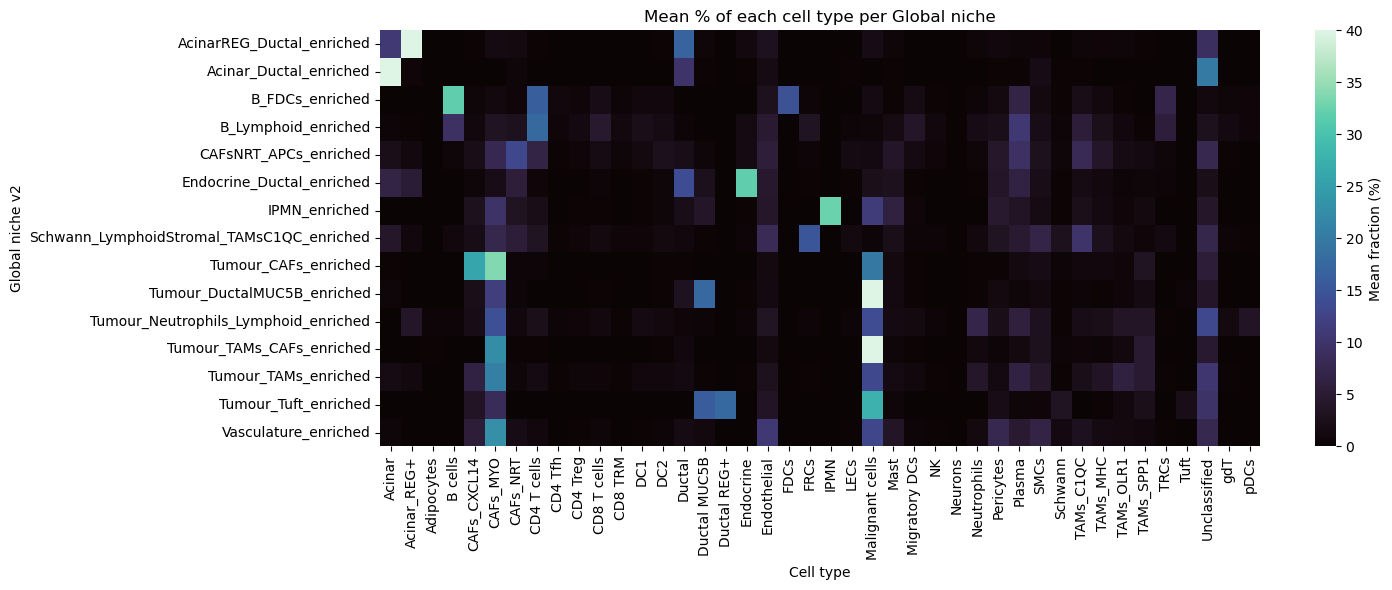

In [34]:
niche_means_names = (
    dfX.join(combined.obs["global_niche_CLR"])
       .groupby("global_niche_CLR")
       .mean()
       .sort_index()
)
# convert to percentage
niche_means_names_pct = niche_means_names * 100.0

# plot
plt.figure(figsize=(15, 6))
sns.heatmap(
    niche_means_names_pct,
    cmap="mako",
    vmax=40,  # adjust for your data
    cbar_kws={"label": "Mean fraction (%)"},
    linewidths=0
)
plt.xlabel("Cell type")
plt.ylabel("Global niche v2")
plt.title("Mean % of each cell type per Global niche")
plt.tight_layout()
plt.show() ## New version

In [7]:
niche_color_map_clr = {
    "Acinar_Ductal_enriched": "#C7EAE5",
    "AcinarREG_Ductal_enriched":  "#01665E",
    "Endocrine_Ductal_enriched": '#e377c2',
    "Tumour_Tuft_enriched":"#7A0177",
    "B_FDCs_enriched": "#FD8D3C",
    "B_Lymphoid_enriched": "#08519C", 
    "CAFsNRT_APCs_enriched":'#c5b0d5',
    "Schwann_LymphoidStromal_TAMsC1QC_enriched":"#FCC5C0",
    "Tumour_Neutrophils_Lymphoid_enriched":'#98df8a',
    "Vasculature_enriched":"#d62728",  
    "Tumour_CAFs_enriched":"#DFC27D",
    "Tumour_TAMs_enriched":"#17becf",
    "Tumour_DuctalMUC5B_enriched":"#92A36F",
    "Tumour_TAMs_CAFs_enriched":"#8c564b", 
    "IPMN_enriched":"#B3B3B3"
}

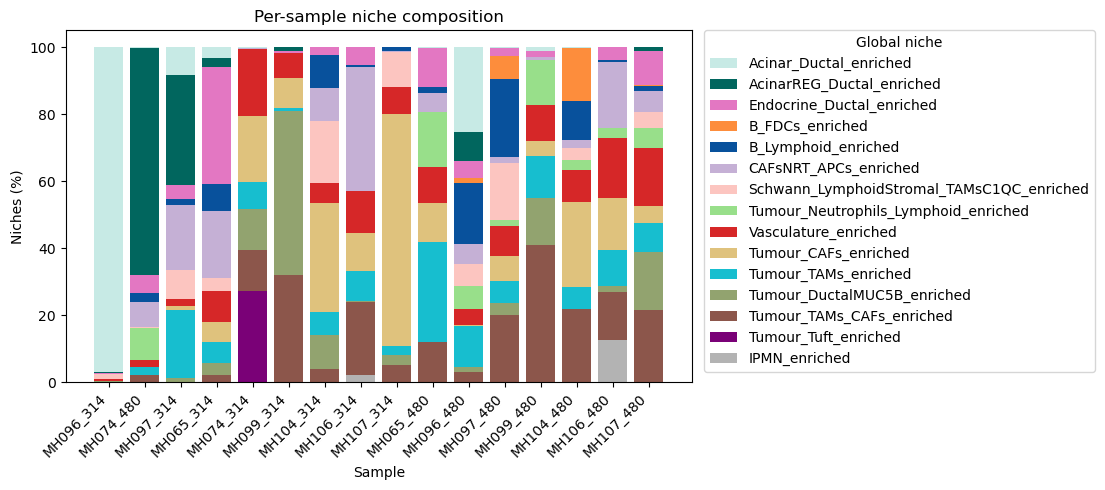

In [38]:
# make sure these exist
assert "sample" in combined.obs.columns
assert "global_niche_CLR" in combined.obs.columns

# count table: rows = samples, cols = niches
ct_counts = pd.crosstab(combined.obs["sample"], combined.obs["global_niche_CLR"])
ct_props  = ct_counts.div(ct_counts.sum(axis=1), axis=0) * 100  # row-wise %

niche_order =["Acinar_Ductal_enriched",
    "AcinarREG_Ductal_enriched",
    "Endocrine_Ductal_enriched",
    "B_FDCs_enriched",
    "B_Lymphoid_enriched", #"#aec7e8",
    "CAFsNRT_APCs_enriched",
    "Schwann_LymphoidStromal_TAMsC1QC_enriched",
    "Tumour_Neutrophils_Lymphoid_enriched",
    "Vasculature_enriched",  
    "Tumour_CAFs_enriched",
    "Tumour_TAMs_enriched",
    "Tumour_DuctalMUC5B_enriched",
    "Tumour_TAMs_CAFs_enriched",
    "Tumour_Tuft_enriched",
    "IPMN_enriched"]

sample_order = ["MH096_314","MH074_480","MH097_314","MH065_314",
                "MH074_314", "MH099_314", "MH104_314", "MH106_314", "MH107_314", 
                "MH065_480", "MH096_480", "MH097_480",
                "MH099_480", "MH104_480", "MH106_480", "MH107_480"]

# keep only those that exist; add any missing to the end (or drop)
niche_order = [n for n in niche_order if n in ct_props.columns] + \
              [n for n in ct_props.columns if n not in niche_order]

# reorder columns
ct_props = ct_props.reindex(columns=niche_order)

# Optional: define desired sample order
sample_order = [s for s in sample_order if s in ct_props.index]
ct_props = ct_props.loc[sample_order]

# consistent colors for niches
niches = ct_props.columns.astype(str)
palette = niche_color_map_clr

# stacked % bar chart (samples on x-axis)
fig, ax = plt.subplots(figsize=(max(10, 0.7*len(ct_props)), 5))

top = np.full(len(ct_props), 100.0)  # start at 100%
x = np.arange(len(ct_props))

for niche in niches:
    vals = ct_props[niche].values
    ax.bar(
        x,
        vals,
        bottom=top - vals,     # position so that we build downward
        label=niche,
        linewidth=0,
        color=palette[niche],
        width=0.8
    )
    top -= vals  

ax.set_xticks(x)
ax.set_xticklabels(ct_props.index, rotation=45, ha="right")
ax.set_ylabel("Niches (%)")
ax.set_xlabel("Sample")
ax.set_title("Per-sample niche composition")
ax.legend(title="Global niche", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
fig.tight_layout()
plt.show()

In [41]:
# z-score 
from scipy.stats import zscore
niche_means_names_z = pd.DataFrame(
    zscore(niche_means_names.values, axis=0, nan_policy="omit"),
    index=niche_means_names.index,
    columns=niche_means_names.columns
)

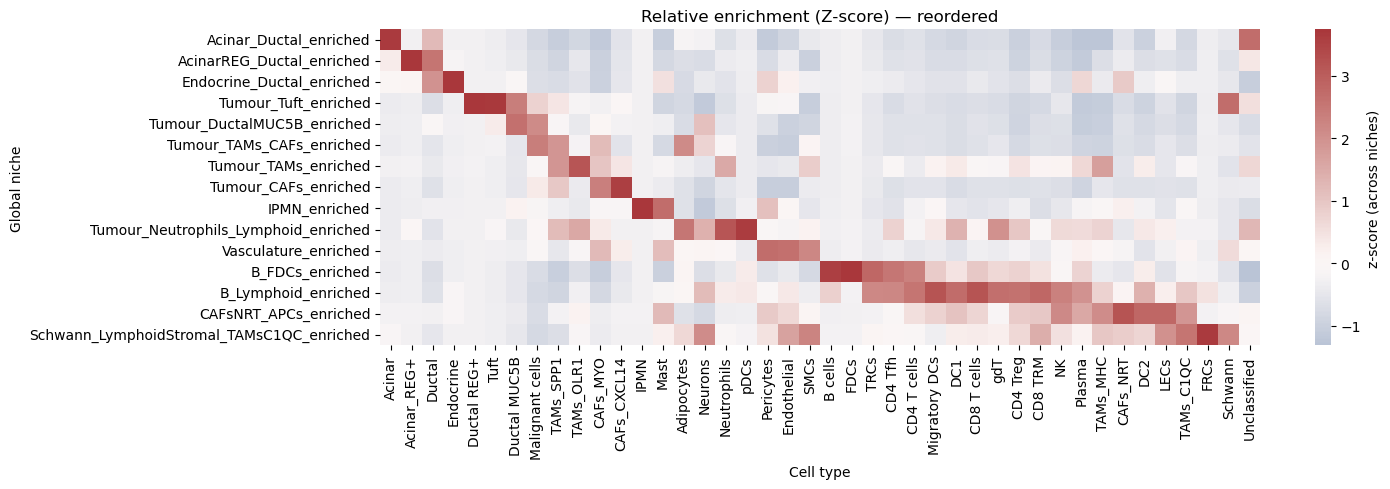

In [59]:
niche_order = ["Acinar_Ductal_enriched", "AcinarREG_Ductal_enriched",
               "Endocrine_Ductal_enriched", "Tumour_Tuft_enriched",
               "Tumour_DuctalMUC5B_enriched","Tumour_TAMs_CAFs_enriched",
              "Tumour_TAMs_enriched", "Tumour_CAFs_enriched", "IPMN_enriched",
               "Tumour_Neutrophils_Lymphoid_enriched","Vasculature_enriched",
               "B_FDCs_enriched", "B_Lymphoid_enriched", #"#aec7e8",
               "CAFsNRT_APCs_enriched", "Schwann_LymphoidStromal_TAMsC1QC_enriched"
               ] 

niche_order = [n for n in niche_order if n in niche_means_names_z.index]


cell_type_order = ["Acinar","Acinar_REG+","Ductal","Endocrine","Ductal REG+","Tuft","Ductal MUC5B",
                   "Malignant cells","TAMs_SPP1","TAMs_OLR1","CAFs_MYO","CAFs_CXCL14",
                   "IPMN","Mast",
                   "Adipocytes","Neurons","Neutrophils","pDCs",
                   "Pericytes","Endothelial", "SMCs",
                   "B cells", "FDCs", "TRCs","CD4 Tfh",
                   "CD4 T cells",
                   "Migratory DCs","DC1",
                   "CD8 T cells", "gdT",
                   "CD4 Treg","CD8 TRM","NK","Plasma","TAMs_MHC",
                   "CAFs_NRT","DC2","LECs","TAMs_C1QC","FRCs", 
                   "Schwann",
                   "Unclassified"
                   
]
cell_type_order = [ct for ct in cell_type_order if ct in niche_means_names_z.columns]

# Reorder DataFrame
#niche_means_z_reordered = niche_means_z.loc[niche_order, niche_means_z.columns[col_order]]
niche_means_z_reordered = niche_means_names_z.loc[niche_order, cell_type_order]

plt.figure(figsize=(15, 5))
sns.heatmap(
    niche_means_z_reordered,
    cmap="vlag",
    center=0,
    #vmax=3,
    #vmin=-1.5,
    cbar_kws={"label": "z-score (across niches)"},
    linewidths=0
)
plt.xlabel("Cell type")
plt.ylabel("Global niche")
plt.title("Relative enrichment (Z-score) — reordered")
plt.tight_layout()
plt.show()

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


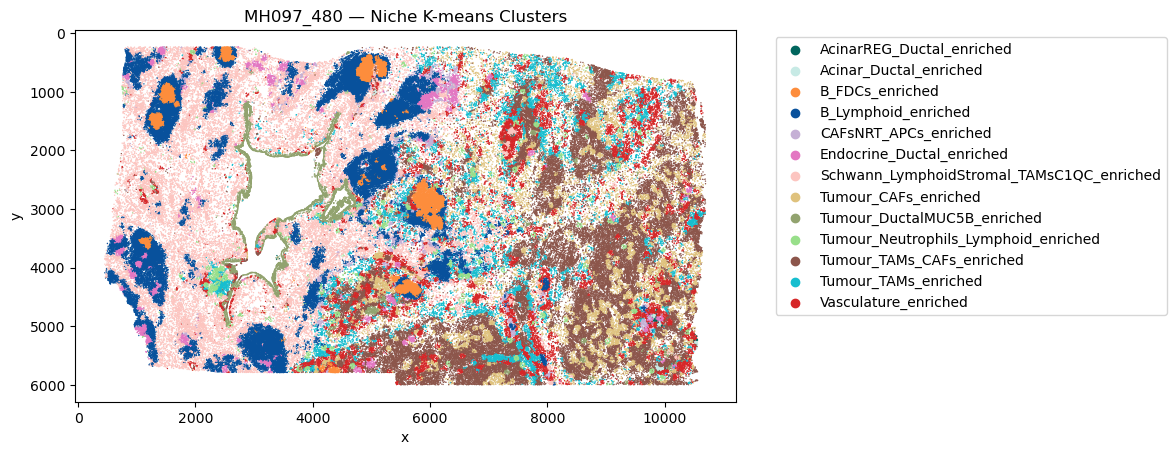

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sample = "MH097_480"  # pick your sample

# subset from combined
ad_one = combined[combined.obs["sample"] == sample].copy()

# make DataFrame for plotting
df_plot = ad_one.obs.copy()
df_plot[["x", "y"]] = ad_one.obsm["spatial"]

# plot with seaborn
plt.figure(figsize=(12, 12))
sns.scatterplot(
    data=df_plot,
    x="x", y="y",
    hue="global_niche_CLR",
    palette=niche_color_map_clr,
    s=1,
    rasterized=True,      
    linewidth=0
)
plt.gca().set_aspect("equal")   
plt.gca().invert_yaxis()        
plt.title(f"{sample} — Niche K-means Clusters")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


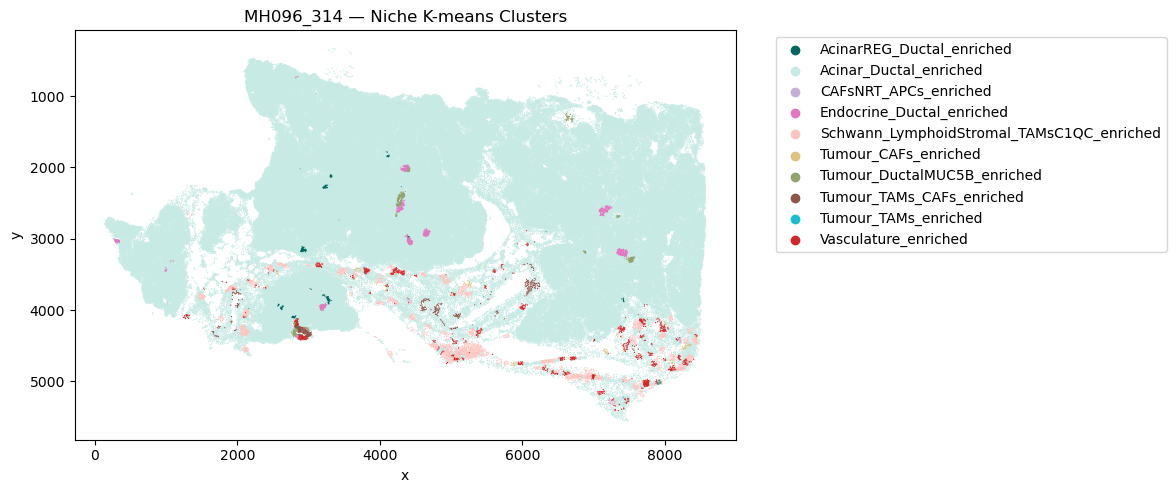

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sample = "MH096_314"  # pick your sample

# subset from combined
ad_one = combined[combined.obs["sample"] == sample].copy()

# make DataFrame for plotting
df_plot = ad_one.obs.copy()
df_plot[["x", "y"]] = ad_one.obsm["spatial"]

# plot with seaborn
plt.figure(figsize=(12, 12))
sns.scatterplot(
    data=df_plot,
    x="x", y="y",
    hue="global_niche_CLR",
    palette=niche_color_map_clr,
    s=1,
    rasterized=True,      
    linewidth=0
)
plt.gca().set_aspect("equal")   
plt.gca().invert_yaxis()      
plt.title(f"{sample} — Niche K-means Clusters")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

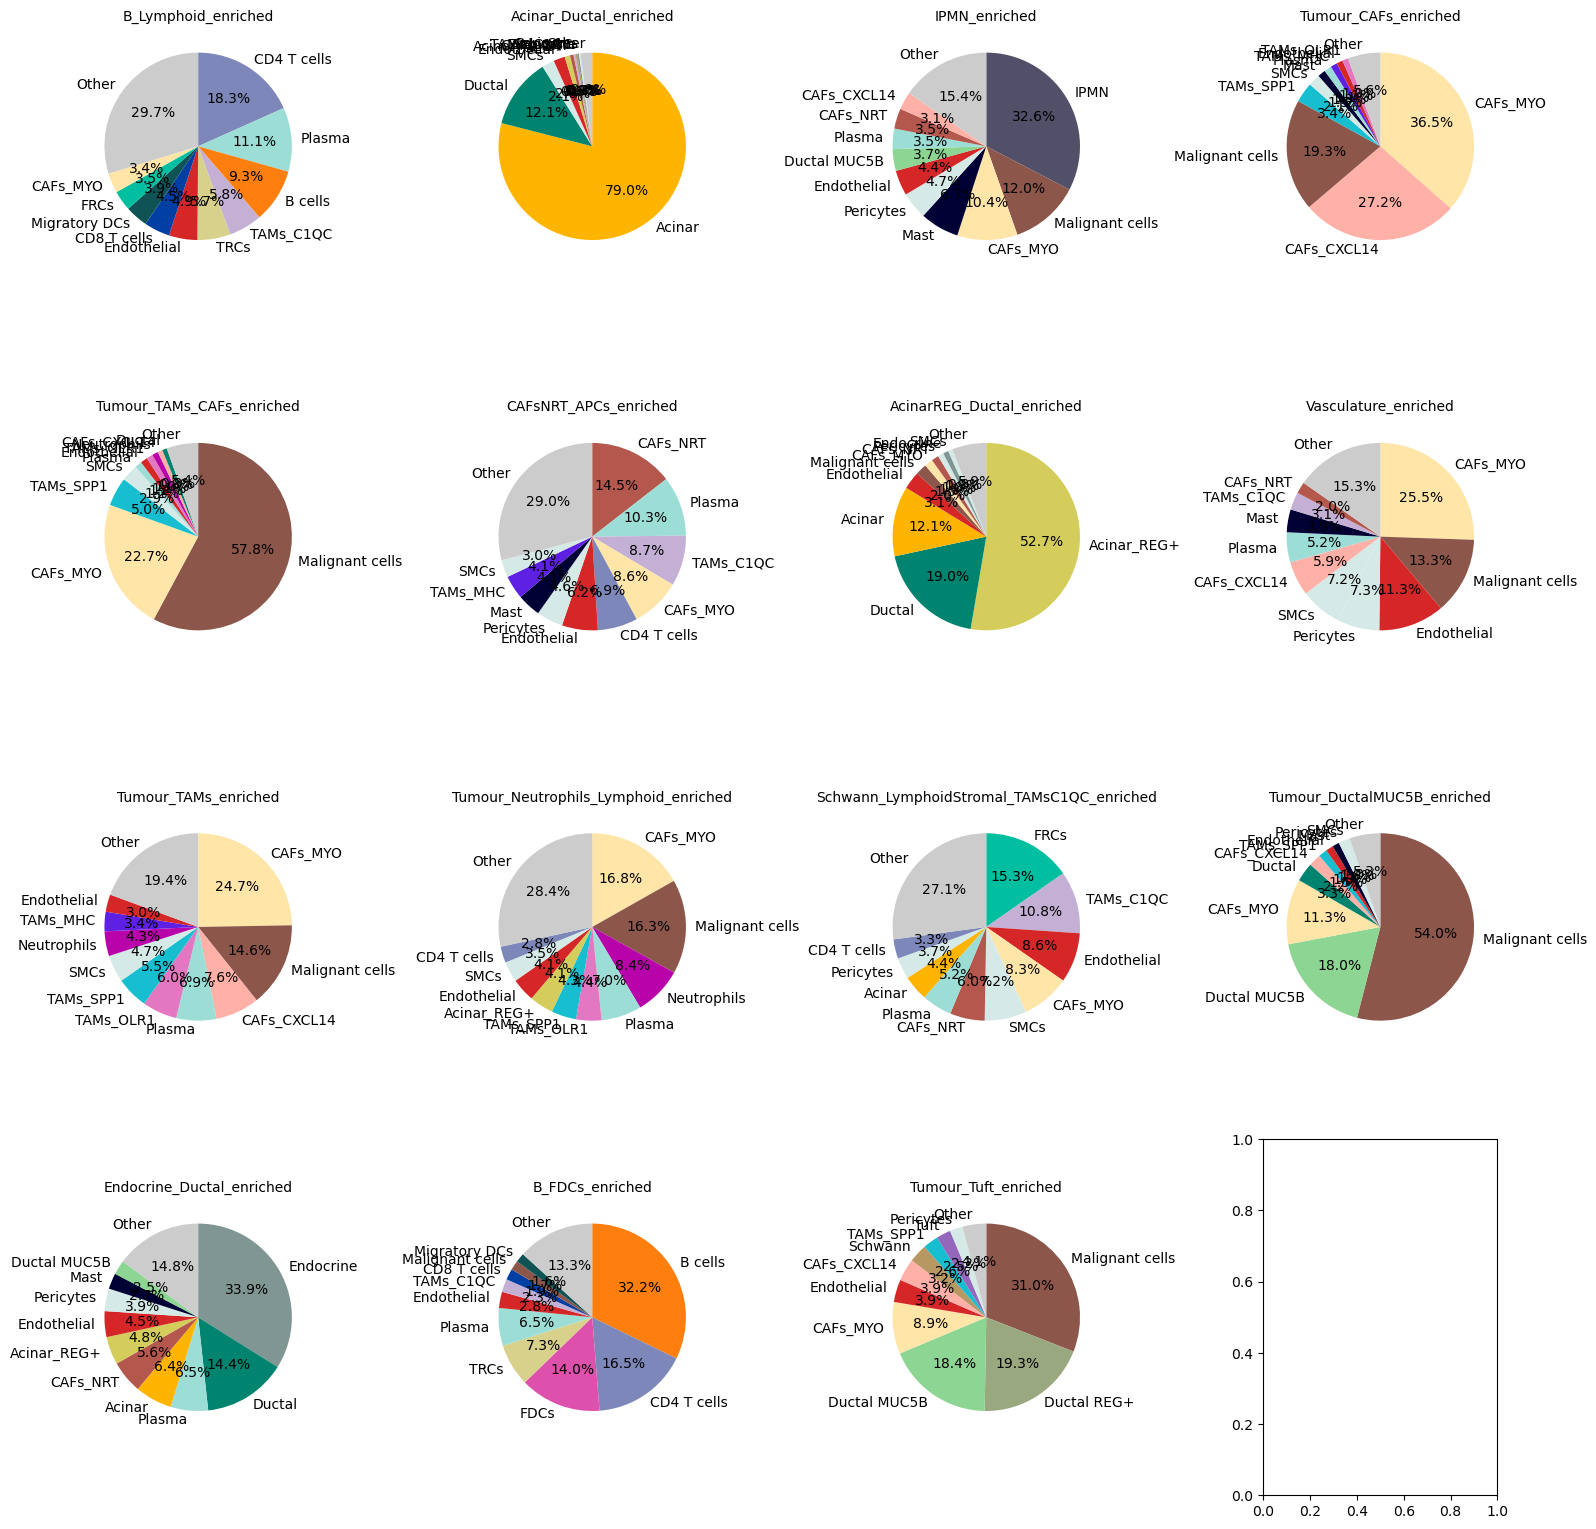

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

label_col = "cell_class_threshold"
all_niches = combined.obs["global_niche_CLR"].unique()
top_n = 10

# Prepare grid layout
n = len(all_niches)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, niche in enumerate(all_niches):
    ax = axes[i]

    # Filter data
    subset = combined.obs.loc[
        (combined.obs["global_niche_CLR"] == niche) &
        (~combined.obs[label_col].isin(["Unclassified", "Unassigned"]))
    ].copy()

    if subset.empty:
        ax.axis("off")
        continue

    # Compute proportions
    pct = (subset[label_col].value_counts(normalize=True) * 100).sort_values(ascending=False)

    top = pct.head(top_n)
    other = pct.iloc[top_n:].sum()
    if other > 0:
        top = pd.concat([top, pd.Series({"Other": other})])

    # Color mapping
    try:
        color_map = manual_colors.copy()
    except NameError:
        color_map = {}

    colors = []
    for ct in top.index:
        if ct == "Other":
            colors.append("#cccccc")
        else:
            colors.append(color_map.get(ct, None))

    # Assign fallback colors
    missing_idx = [i for i, c in enumerate(colors) if c is None]
    if missing_idx:
        pal = sns.color_palette("tab10", n_colors=len(missing_idx))
        for i_missing, p in zip(missing_idx, pal):
            colors[i_missing] = p

    # Plot
    ax.pie(
        top.values,
        labels=top.index,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        colors=colors
    )
    ax.set_title(niche, fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_320638/218047432.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filtered.groupby(["global_niche_CLR", "sample"])
/tmp/ipykernel_320638/218047432.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("tab20b", len(samples))


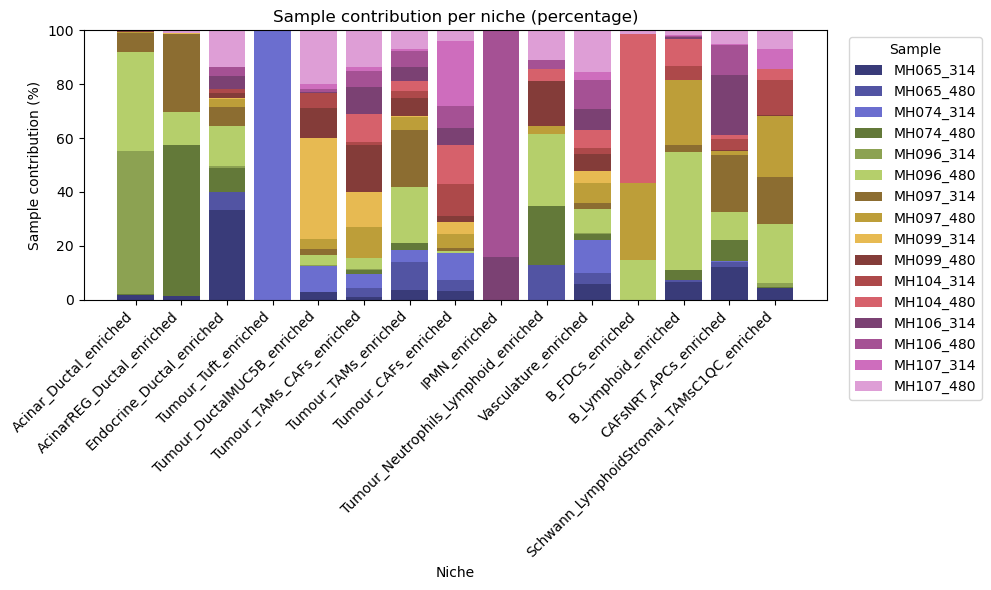

In [84]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap

niche_order = ["Acinar_Ductal_enriched", "AcinarREG_Ductal_enriched",
               "Endocrine_Ductal_enriched", "Tumour_Tuft_enriched",
               "Tumour_DuctalMUC5B_enriched","Tumour_TAMs_CAFs_enriched",
              "Tumour_TAMs_enriched", "Tumour_CAFs_enriched", "IPMN_enriched",
               "Tumour_Neutrophils_Lymphoid_enriched","Vasculature_enriched",
               "B_FDCs_enriched", "B_Lymphoid_enriched", #"#aec7e8",
               "CAFsNRT_APCs_enriched", "Schwann_LymphoidStromal_TAMsC1QC_enriched"]


# 1. Filter out unclassified cells
label_col = "global_niche_CLR"
filtered = combined.obs.loc[
    ~combined.obs[label_col].isin(["Unclassified", "Unassigned"])
]

# 2. Group by niche and sample to get counts
counts_by_niche_sample = (
    filtered.groupby(["global_niche_CLR", "sample"])
            .size()
            .unstack(fill_value=0)  # rows = niches, columns = samples
)

# 3. Convert to percentages (row-wise)
counts_pct = counts_by_niche_sample.div(counts_by_niche_sample.sum(axis=1), axis=0) * 100

# Filter and reorder to include only the niches in your desired order
counts_pct = counts_pct.loc[
    counts_pct.index.intersection(niche_order)  
]

# Reording niche
counts_pct = counts_pct.reindex(niche_order)

# Reorder sample columns
sample_order = ["MH065_314", "MH065_480","MH074_314", "MH074_480","MH096_314","MH096_480",
                "MH097_314","MH097_480","MH099_314", "MH099_480","MH104_314","MH104_480",
                "MH106_314", "MH106_480","MH107_314", "MH107_480"
]


# 4. Set up color map for samples using "Paired"
samples = [s for s in sample_order if s in counts_pct.columns]
cmap = get_cmap("tab20b", len(samples))
sample_colors = {sample: cmap(i % cmap.N) for i, sample in enumerate(samples)}

# 5. Plot stacked percentage bar
fig, ax = plt.subplots(figsize=(max(10, 0.6 * len(counts_pct)), 6))

bottom = np.zeros(len(counts_pct))
x = np.arange(len(counts_pct))
niches = counts_pct.index

for sample in samples:
    vals = counts_pct[sample].values
    ax.bar(
        x, vals, bottom=bottom,
        label=sample,
        color=sample_colors[sample],
        width=0.8
    )
    bottom += vals

# Labeling
ax.set_xticks(x)
ax.set_xticklabels(niches, rotation=45, ha="right")
ax.set_ylabel("Sample contribution (%)")
ax.set_xlabel("Niche")
ax.set_title("Sample contribution per niche (percentage)")
ax.set_ylim(0, 100)
ax.legend(title="Sample", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

In [10]:
manual_colors = {
    'Acinar': '#ffb500',
    'Acinar_REG+': '#d4cd5c', #'#17becf', #
    'Adipocytes': 'black',
    'B cells':  '#ff7f0e',
    'CAFs_CXCL14':'#FFB0A7',
    'CAFs_MYO': '#FFE5A7', #'#c7c7c7',
    'CAFs_NRT': "#B4584D",
    "CD4 T cells":  '#7d87b9',
    "CD4 Tfh" : "#46487E",
    "CD4 Treg": '#536CC7',
    "CD8 T cells":'#023fa5',
    "CD8 TRM": "#0A295E",
    "DC1": "#888D07",
    "DC2": "#717417", 
    "Ductal": '#00846f',
    "Ductal MUC5B":'#8dd593',
    "Endocrine": '#809693',
    "Endothelial":'#d62728',
    "FDCs":"#DD51AD",
    "FRCs": "#00BFA0",
    "LECs": "#535A06",
    "TRCs": '#D8D18C',
    "Malignant cells": '#8c564b',
    "Mast": '#000035',
    "Migratory DCs": "#105354",
    "NK": "#00025E",
    "Neutrophils": '#b903aa',
    "Pericytes": '#d5eae7', #'#c5b0d5',
    "Plasma": '#9cded6',
    "SMCs": '#d5eae7', #'#c5b0d5',
    "Schwann": '#b79762',
    "TAMs_C1QC":'#c5b0d5',
    "TAMs_MHC": "#5E21E3",
    "TAMs_OLR1":'#e377c2',
    "TAMs_SPP1": '#17becf',
    "Unclassified": "#cccccc",
    "gdT": '#000035', 
    "pDCs":'#1b4400',
    "Tuft": '#9467bd',
    "IPMN": "#525068",
    "Ductal REG+": "#9aa880",
    "Other": "#cccccc"
}

/tmp/ipykernel_431730/1519004451.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby(["sample", label_col])


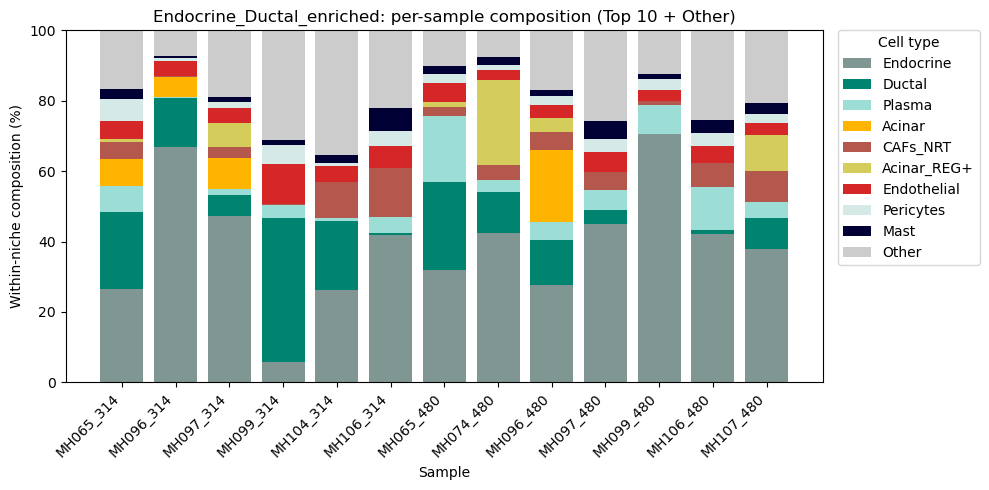

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

niche = "Endocrine_Ductal_enriched" 
label_col = "cell_class_threshold"

# Subset to niche and exclude unwanted labels
subset = combined.obs.loc[
    (combined.obs["global_niche_CLR"] == niche)
    & (~combined.obs[label_col].isin(["Unclassified", "Unassigned"]))
].copy()

if subset.empty:
    raise ValueError(f"No cells found in niche '{niche}' after exclusions.")
subset = subset.loc[subset["sample"] != "MH104_480"] # for some reason, couldn't remove, have to manually discard for plotting
    
# Top cell types contributing to the niche
top8 = subset[label_col].value_counts().head(9).index.tolist()

# Per-sample counts pivot (samples x cell types)
counts = (
    subset.groupby(["sample", label_col])
          .size()
          .unstack(fill_value=0)
)
counts = counts[counts.sum(axis=1) > 0]

# ensure all top8 columns exist even if some samples miss them
for ct in top8:
    if ct not in counts.columns:
        counts[ct] = 0

# 4) Row-wise % and collapse others into "Other"
row_totals = counts.sum(axis=1).replace(0, np.nan)
perc = counts.div(row_totals, axis=0) * 100

perc_top8 = perc[top8]                      
perc_other = 100 - perc_top8.sum(axis=1)    # collapse rest
plot_df = perc_top8.copy()
plot_df["Other"] = perc_other.clip(lower=0) 
plot_df = plot_df.fillna(0)

# 5) Plot stacked bar per sample
fig, ax = plt.subplots(figsize=(max(10, 0.7*len(plot_df)), 5))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df))
cols = top8 + ["Other"]

# optional: reuse your manual color map; fallback to grey for "Other"
try:
    color_map = manual_colors.copy()
except NameError:
    color_map = {}
color_map.setdefault("Other", "#cccccc")

for col in cols:
    vals = plot_df[col].values
    ax.bar(
        x, vals, bottom=bottom,
        label=col,
        color=color_map.get(col, "#cccccc"),
        width=0.8, linewidth=0
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index.astype(str), rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Within-niche composition (%)")
ax.set_xlabel("Sample")
ax.set_title(f"{niche}: per-sample composition (Top 10 + Other)")
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
fig.tight_layout()
plt.show()

/tmp/ipykernel_431730/2344833923.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby(["sample", label_col])


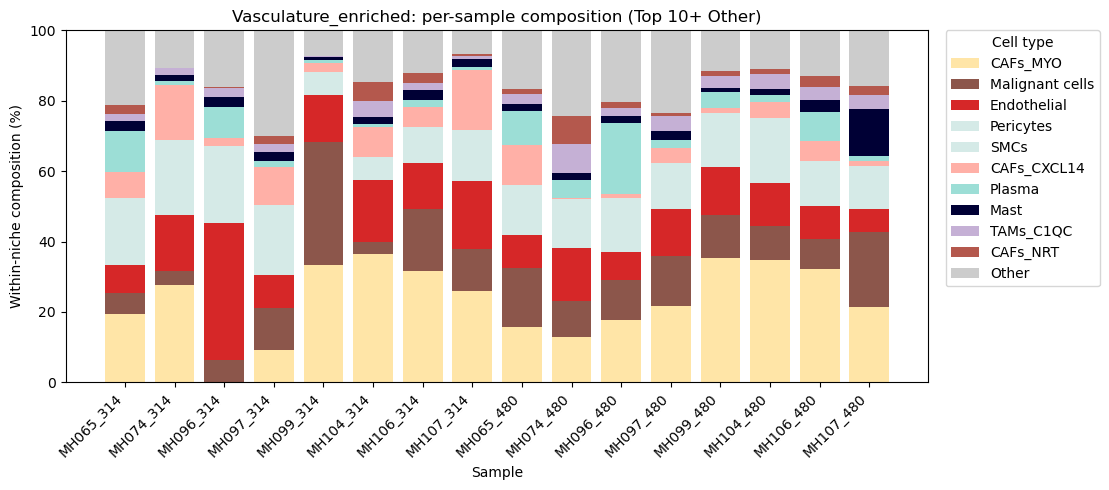

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

niche = "Vasculature_enriched" 
label_col = "cell_class_threshold"

# Subset to niche and exclude unwanted labels
subset = combined.obs.loc[
    (combined.obs["global_niche_CLR"] == niche)
    & (~combined.obs[label_col].isin(["Unclassified", "Unassigned"]))
].copy()

if subset.empty:
    raise ValueError(f"No cells found in niche '{niche}' after exclusions.")

# Top cell classes within this niche
top8 = subset[label_col].value_counts().head(10).index.tolist()

# Per-sample counts pivot (samples x cell types)
counts = (
    subset.groupby(["sample", label_col])
          .size()
          .unstack(fill_value=0)
)
counts = counts[counts.sum(axis=1) > 0]

for ct in top8:
    if ct not in counts.columns:
        counts[ct] = 0

# 4) Row-wise % and collapse others into "Other"
row_totals = counts.sum(axis=1).replace(0, np.nan)
perc = counts.div(row_totals, axis=0) * 100

perc_top8 = perc[top8]                    
perc_other = 100 - perc_top8.sum(axis=1)    # collapse rest
plot_df = perc_top8.copy()
plot_df["Other"] = perc_other.clip(lower=0) # numeric safety
plot_df = plot_df.fillna(0)


# 5) Plot stacked bar per sample
fig, ax = plt.subplots(figsize=(max(10, 0.7*len(plot_df)), 5))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df))
cols = top8 + ["Other"]

try:
    color_map = manual_colors.copy()
except NameError:
    color_map = {}
color_map.setdefault("Other", "#cccccc")

for col in cols:
    vals = plot_df[col].values
    ax.bar(
        x, vals, bottom=bottom,
        label=col,
        color=color_map.get(col, "#cccccc"),
        width=0.8, linewidth=0
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index.astype(str), rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Within-niche composition (%)")
ax.set_xlabel("Sample")
ax.set_title(f"{niche}: per-sample composition (Top 10+ Other)")
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
fig.tight_layout()
plt.savefig("figures/Vasculature_niche_acrossPatients.pdf", dpi=300)
plt.show()